**Set Up & Read Data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re # Regular Expressions
import string
import warnings
from bs4 import BeautifulSoup
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
warnings.filterwarnings("ignore")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
from IPython.display import display

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
#from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    log_loss,
    roc_auc_score,
    classification_report,
    hinge_loss,
)

SEED = 42
np.random.seed(SEED)

MAX_FEATURES = 10_000
TEST_SIZE = 0.20
MAX_ITER = 1000

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 100)



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.8/114.8 kB 7.0 MB/s eta 0:00:00


In [ ]:
import contractions

In [ ]:
DATA_PATH ='/content/IMDB Dataset.csv'
df = pd.read_csv(DATA_PATH)

assert df.shape == (50_000, 2)

expected_columns = {"review", "sentiment"}
assert expected_columns.issubset(df.columns)

display(df.head())
print("\nColumn data types:")
display(df.dtypes)

,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as ...",positive
1,A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and g...,positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater...",positive
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fightin...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portr...",positive



Column data types:


,0
review,object
sentiment,object


In [ ]:
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicated Reviews =", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None

Missing Values
review       0
sentiment    0
dtype: int64

Duplicated Reviews = 418


In [ ]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(df.shape)

(49582, 2)


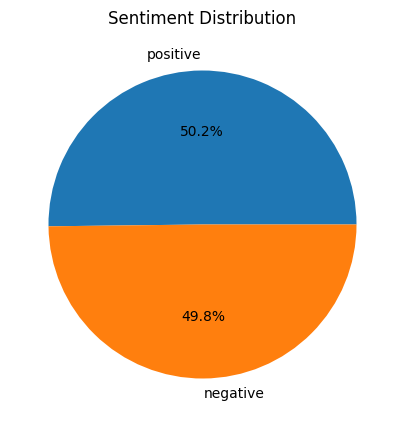

In [ ]:
plt.figure(figsize=(5,5))

df["sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Sentiment Distribution")
plt.show()

**Some Preprocessing**

In [ ]:

label_map = {"negative": 0, "positive": 1}
df["sentiment"] = df["sentiment"].map(label_map).astype(np.int8)

print("Binary labels:")
print(df["sentiment"].value_counts().sort_index())

assert set(df["sentiment"].unique()) == {0, 1}
print("\nMapping:")
print("negative -> 0")
print("positive -> 1")


Binary labels:
sentiment
0    24698
1    24884
Name: count, dtype: int64

Mapping:
negative -> 0
positive -> 1


In [ ]:
stop_words = set(stopwords.words("english"))
negation_words = {"no", "nor", "not", "never", "cannot", "n't"}
clause_breakers = {"but", "however", "although", "though", "yet"}
stop_words_for_removal = stop_words - negation_words - clause_breakers

lemmatizer = WordNetLemmatizer()

In [ ]:
def remove_html(text):
    return BeautifulSoup(text, "html.parser").get_text()

def remove_urls(text):
    return re.sub(r"http\S+|www\S+", " ", text)

def reduce_elongated_words(text):
    return re.sub(r"(.)\1{2,}", r"\1\1", text)

def mark_negation(text):
    tokens = re.findall(r"[a-zA-Z]+|[!?.,]", text)

    result = []
    negate = False

    for tok in tokens:

        if tok in {"!", "?", ".", ","}:
            negate = False
            continue

        if tok in negation_words:
            negate = True
            continue

        if tok in clause_breakers:
            negate = False
            result.append(tok)
            continue

        result.append("NOT_" + tok if negate else tok)

    return " ".join(result)

def remove_stopwords(text):
    words = text.split()
    kept = [
        w for w in words
        if w.startswith("NOT_") or w not in stop_words_for_removal
    ]
    return " ".join(kept)

def lemmatize_text(text):
    words = text.split()
    lemmatized = []
    for w in words:
        if w.startswith("NOT_"):
            base = w[4:]
            lemmatized.append("NOT_" + lemmatizer.lemmatize(base, pos="v"))
        else:
            lemmatized.append(lemmatizer.lemmatize(w, pos="v"))
    return " ".join(lemmatized)

def remove_emails(text):
    return re.sub(r"\S+@\S+", " ", text)

def expand_contractions(text):
    return contractions.fix(text)

def remove_html_entities(text):
    text = re.sub(r"&amp;", " and ", text)
    text = re.sub(r"&lt;", " ", text)
    text = re.sub(r"&gt;", " ", text)
    return text

def remove_special_characters(text):
    return re.sub(r"[^a-zA-Z!? ]", " ", text)

def remove_extra_spaces(text):
    return re.sub(r"\s+", " ", text).strip()


In [ ]:
def clean_text(text):
    text = text.lower()
    text = remove_html(text)
    text = remove_urls(text)
    text = remove_emails(text)
    text = expand_contractions(text)
    text = remove_html_entities(text)
    text = reduce_elongated_words(text)

    # IMPORTANT:
    # Mark negation BEFORE removing punctuation
    text = mark_negation(text)

    text = remove_special_characters(text)
    text = remove_stopwords(text)
    text = lemmatize_text(text)
    text = remove_extra_spaces(text)

    return text

In [ ]:
df["clean_review"] = df["review"].apply(clean_text)
df = df[df["clean_review"].str.strip() != ""]
df.reset_index(drop=True, inplace=True)
print(df.shape)

(49582, 3)


In [ ]:
test_sentences = [
    "this movie is great",
    "this movie is not great",
    "this movie is excellent",
    "this movie is not excellent",
    "this movie is perfect",
    "this movie is not perfect",
    "this movie is terrible",
    "this movie is not terrible"
]

for sentence in test_sentences:
    print(sentence)
    print("→", clean_text(sentence))
    print()

this movie is great
→ movie great

this movie is not great
→ movie NOT great

this movie is excellent
→ movie excellent

this movie is not excellent
→ movie NOT excellent

this movie is perfect
→ movie perfect

this movie is not perfect
→ movie NOT perfect

this movie is terrible
→ movie terrible

this movie is not terrible
→ movie NOT terrible



In [ ]:
df.head()

,review,sentiment,clean_review
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as ...",1,one reviewers mention watch oz episode hook right exactly happen first thing strike oz brutality unflinching scenes ...
1,A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and g...,1,wonderful little production film technique unassuming old time bbc fashion give comfort sometimes discomforting sens...
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater...",1,think wonderful way spend time hot summer weekend sit air condition theater watch light hearted comedy plot simplist...
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fightin...,0,basically family little boy jake think zombie closet parent fight time movie slower soap opera suddenly jake decide ...
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portr...",1,petter mattei love time money visually stun film watch mr mattei offer us vivid portrait human relations movie seem ...


In [ ]:
print("ORIGINAL REVIEW")
print(df["review"][0])
print()

print("CLEAN REVIEW")
print(df["clean_review"][0])

ORIGINAL REVIEW
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show i

**Split data & Handle Models**

In [ ]:
X_text = df["clean_review"]
y = df["sentiment"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y,
)

print(f"Total samples    : {len(df):,}")
print(f"Training samples : {len(X_train_text):,}")
print(f"Testing samples  : {len(X_test_text):,}")

print(f"\nTraining ratio: {len(X_train_text) / len(df):.2%}")
print(f"Testing ratio : {len(X_test_text) / len(df):.2%}")


Total samples    : 49,582
Training samples : 39,665
Testing samples  : 9,917

Training ratio: 80.00%
Testing ratio : 20.00%


In [ ]:
"""vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    lowercase=True,
    stop_words=None,
    max_features=MAX_FEATURES,
    min_df=10,
    max_df=0.9,
    sublinear_tf=True,
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)
feature_names = vectorizer.get_feature_names_out()
print("Number of features:", len(feature_names))
print("\nTF-IDF Training shape  :", X_train.shape)
print("TF-IDF Testing shape   :", X_test.shape)

assert X_train.shape[0] == len(y_train)
assert X_test.shape[0] == len(y_test)"""

'vectorizer = TfidfVectorizer(\n    ngram_range=(1, 2),\n    lowercase=True,\n    stop_words=None,\n    max_features=MAX_FEATURES,\n    min_df=10,\n    max_df=0.9,\n    sublinear_tf=True,\n)\n\nX_train = vectorizer.fit_transform(X_train_text)\nX_test = vectorizer.transform(X_test_text)\nfeature_names = vectorizer.get_feature_names_out()\nprint("Number of features:", len(feature_names))\nprint("\nTF-IDF Training shape  :", X_train.shape)\nprint("TF-IDF Testing shape   :", X_test.shape)\n\nassert X_train.shape[0] == len(y_train)\nassert X_test.shape[0] == len(y_test)'

In [ ]:
vectorizer = CountVectorizer(
    ngram_range=(1, 2),
    lowercase=True,
    stop_words=None,
    max_features=MAX_FEATURES,
    binary=False,
    min_df=10,
    max_df=0.9,
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)
feature_names = vectorizer.get_feature_names_out()
print("Number of features:", len(feature_names))
print("\nBoW Training shape:", X_train.shape)
print("BoW Testing shape :", X_test.shape)

assert X_train.shape[0] == len(y_train)
assert X_test.shape[0] == len(y_test)

Number of features: 10000

BoW Training shape: (39665, 10000)
BoW Testing shape : (9917, 10000)


In [ ]:
print("First 30 features:")
print(feature_names[:30])

print("\nNumber of unigram/bigram features:")
unigrams = sum(" " not in feature for feature in feature_names)
bigrams = sum(" " in feature for feature in feature_names)

print("Unigrams:", unigrams)
print("Bigrams :", bigrams)

First 30 features:
['aaron' 'abandon' 'abbott' 'abc' 'abilities' 'ability' 'able' 'able not'
 'aboard' 'abortion' 'abound' 'abraham' 'abrupt' 'abruptly' 'absence'
 'absent' 'absolute' 'absolutely' 'absolutely love' 'absolutely not'
 'absolutely nothing' 'absorb' 'abstract' 'absurd' 'absurdity' 'abuse'
 'abusive' 'abysmal' 'academy' 'academy award']

Number of unigram/bigram features:
Unigrams: 5811
Bigrams : 4189


**Train & Test The Models**

In [ ]:
model = LogisticRegression(
    solver="lbfgs",
    penalty="l2",
    max_iter=MAX_ITER,
    random_state=SEED,
)
model.fit(X_train, y_train)

print("Logistic Regression trained with default parameters.")
print(f"C used (sklearn default): {model.C}")

Logistic Regression trained with default parameters.
C used (sklearn default): 1.0


C = 0.01   -> Mean CV Accuracy = 0.8946
C = 0.1    -> Mean CV Accuracy = 0.8819
C = 1      -> Mean CV Accuracy = 0.8747
C = 10     -> Mean CV Accuracy = 0.8735
C = 100    -> Mean CV Accuracy = 0.8735


,C,Mean CV Accuracy
0,0.01,0.894567
1,0.10,0.881936
2,1.00,0.874675
3,10.00,0.873490
4,100.00,0.873490



Best C for SVC: 0.01 (Mean CV Accuracy = 0.8946)


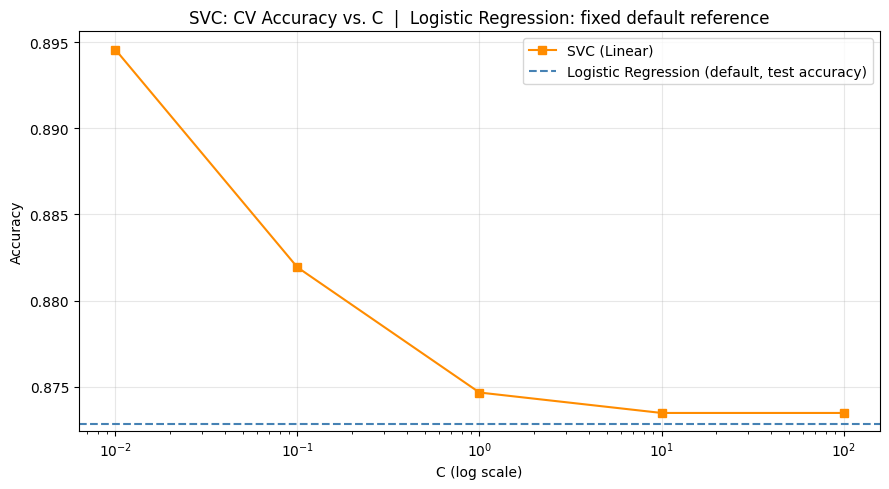

In [ ]:
C_GRID = [0.01, 0.1, 1, 10, 100]
svc_results = []

for C in C_GRID:
    candidate = CalibratedClassifierCV(
        LinearSVC(C=C, max_iter=MAX_ITER, random_state=SEED),
        method="sigmoid",
        cv=3,
    )
    cv_scores = cross_val_score(candidate, X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1)
    cv_accuracy = cv_scores.mean()
    svc_results.append({"C": C, "Mean CV Accuracy": cv_accuracy})
    print(f"C = {C:<6} -> Mean CV Accuracy = {cv_accuracy:.4f}")

svc_results_df = pd.DataFrame(svc_results)
display(svc_results_df)

best_row = max(svc_results, key=lambda r: r["Mean CV Accuracy"])
best_svc_C = best_row["C"]

# Refit the winning C on the full training set to get the final model
svc_model = CalibratedClassifierCV(
    LinearSVC(C=best_svc_C, max_iter=MAX_ITER, random_state=SEED),
    method="sigmoid",
    cv=3,
)
svc_model.fit(X_train, y_train)

print(f"\nBest C for SVC: {best_svc_C} (Mean CV Accuracy = {best_row['Mean CV Accuracy']:.4f})")

plt.figure(figsize=(9, 5))
plt.plot(svc_results_df["C"], svc_results_df["Mean CV Accuracy"], marker="s", color="darkorange", label="SVC (Linear)")
plt.axhline(
    accuracy_score(y_test, model.predict(X_test)),
    color="steelblue", linestyle="--", label="Logistic Regression (default, test accuracy)"
)
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("Accuracy")
plt.title("SVC: CV Accuracy vs. C  |  Logistic Regression: fixed default reference")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
test_probabilities = model.predict_proba(X_test)[:, 1]
test_predictions = (test_probabilities >= 0.5).astype(int)

test_logloss = log_loss(y_test, test_probabilities, labels=[0, 1])
accuracy = accuracy_score(y_test, test_predictions)
precision = precision_score(y_test, test_predictions, zero_division=0)
recall = recall_score(y_test, test_predictions, zero_division=0)
f1 = f1_score(y_test, test_predictions, zero_division=0)
roc_auc = roc_auc_score(y_test, test_probabilities)

cm = confusion_matrix(y_test, test_predictions, labels=[0, 1])

print(f"Logistic Regression (C = {model.C})")
print("\n2 x 2 Confusion Matrix")
display(pd.DataFrame(
    cm,
    index=["True Negative (0)", "True Positive (1)"],
    columns=["Predicted Negative (0)", "Predicted Positive (1)"],
))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=["Negative", "Positive"],
        digits=4,
        zero_division=0,
    )
)


svc_probabilities = svc_model.predict_proba(X_test)[:, 1]
svc_predictions = (svc_probabilities >= 0.5).astype(int)

svc_logloss = log_loss(y_test, svc_probabilities, labels=[0, 1])
svc_accuracy = accuracy_score(y_test, svc_predictions)
svc_precision = precision_score(y_test, svc_predictions, zero_division=0)
svc_recall = recall_score(y_test, svc_predictions, zero_division=0)
svc_f1 = f1_score(y_test, svc_predictions, zero_division=0)
svc_roc_auc = roc_auc_score(y_test, svc_probabilities)

svc_cm = confusion_matrix(y_test, svc_predictions, labels=[0, 1])

print(f"SVC (Linear) — best C = {best_svc_C}")
print("\n2 x 2 Confusion Matrix")
display(pd.DataFrame(
    svc_cm,
    index=["True Negative (0)", "True Positive (1)"],
    columns=["Predicted Negative (0)", "Predicted Positive (1)"],
))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        svc_predictions,
        target_names=["Negative", "Positive"],
        digits=4,
        zero_division=0,
    )
)

Logistic Regression (C = 1.0)

2 x 2 Confusion Matrix


,Predicted Negative (0),Predicted Positive (1)
True Negative (0),4320,620
True Positive (1),641,4336



Classification Report:
              precision    recall  f1-score   support

    Negative     0.8708    0.8745    0.8726      4940
    Positive     0.8749    0.8712    0.8730      4977

    accuracy                         0.8728      9917
   macro avg     0.8728    0.8729    0.8728      9917
weighted avg     0.8729    0.8728    0.8728      9917

SVC (Linear) — best C = 0.01

2 x 2 Confusion Matrix


,Predicted Negative (0),Predicted Positive (1)
True Negative (0),4389,551
True Positive (1),483,4494



Classification Report:
              precision    recall  f1-score   support

    Negative     0.9009    0.8885    0.8946      4940
    Positive     0.8908    0.9030    0.8968      4977

    accuracy                         0.8957      9917
   macro avg     0.8958    0.8957    0.8957      9917
weighted avg     0.8958    0.8957    0.8957      9917



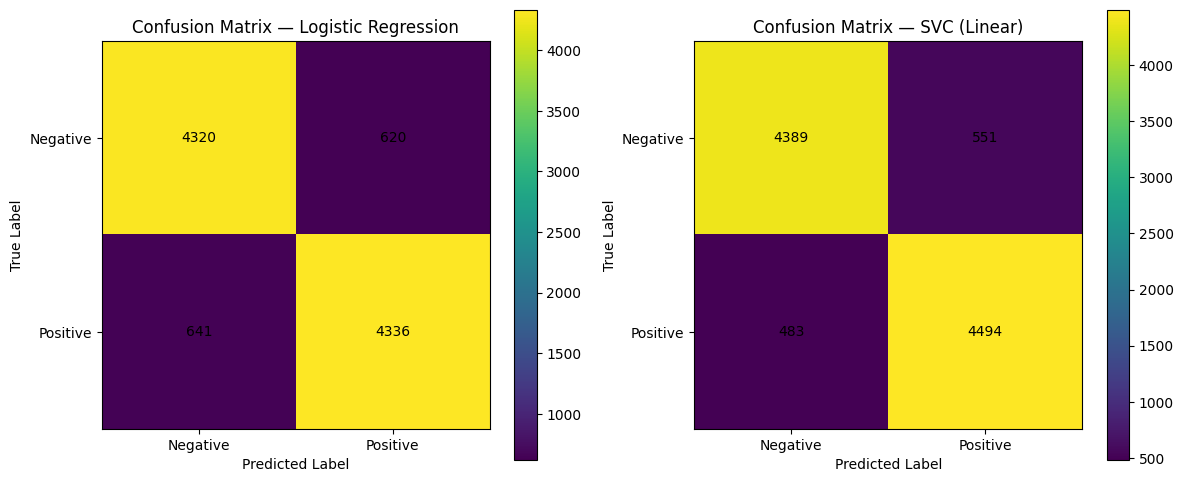

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, matrix, title in zip(axes, [cm, svc_cm], ["Logistic Regression", "SVC (Linear)"]):
    im = ax.imshow(matrix)
    ax.set_title(f"Confusion Matrix — {title}")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Negative", "Positive"])
    ax.set_yticklabels(["Negative", "Positive"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, matrix[i, j], ha="center", va="center")
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

In [ ]:
comparison_table = pd.DataFrame({
    "Model": ["Logistic Regression", "SVC (Linear)"],
    "C": [model.C, best_svc_C],
    "Accuracy": [accuracy, svc_accuracy],
    "Precision": [precision, svc_precision],
    "Recall": [recall, svc_recall],
    "F1-Score": [f1, svc_f1],
    "ROC-AUC": [roc_auc, svc_roc_auc],
    "Log Loss": [test_logloss, svc_logloss],
})

display(
    comparison_table.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "Log Loss": "{:.4f}",
    }).highlight_max(subset=["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"], color="lightgreen")
     .highlight_min(subset=["Log Loss"], color="lightgreen")
)

best_model_name = comparison_table.loc[comparison_table["Accuracy"].idxmax(), "Model"]
print(f"\nHighest Accuracy model: {best_model_name}")

,Model,C,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Log Loss
0,Logistic Regression,1.000000,0.8728,0.8749,0.8712,0.8730,0.9436,0.4199
1,SVC (Linear),0.010000,0.8957,0.8908,0.9030,0.8968,0.9593,0.2642



Highest Accuracy model: SVC (Linear)


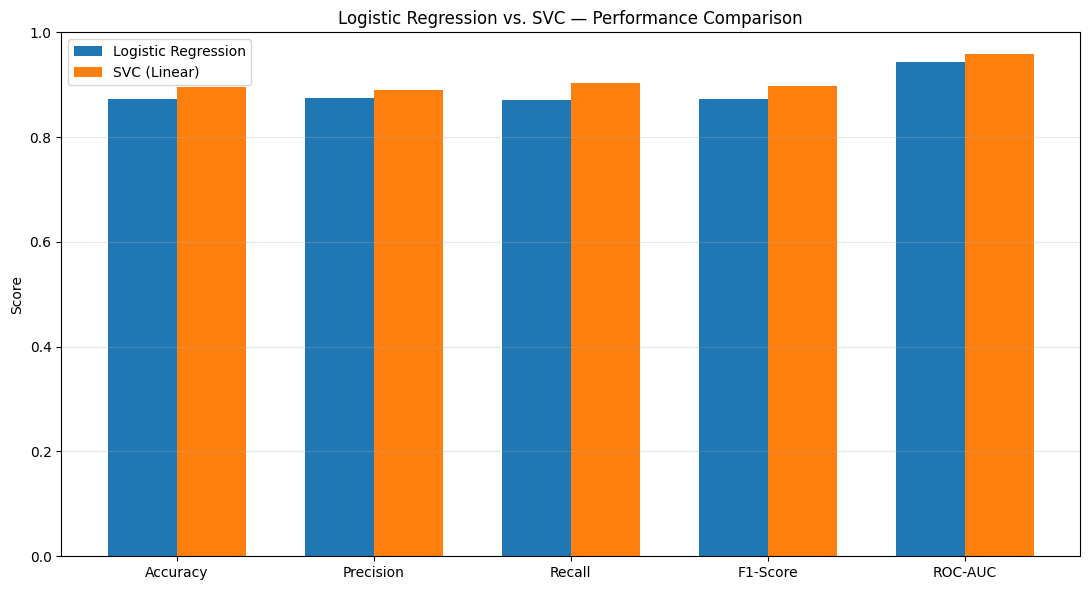

In [ ]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(metrics_to_plot))
width = 0.35

lr_values = comparison_table.loc[0, metrics_to_plot].values
svc_values = comparison_table.loc[1, metrics_to_plot].values

ax.bar(x - width / 2, lr_values, width, label="Logistic Regression")
ax.bar(x + width / 2, svc_values, width, label="SVC (Linear)")

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel("Score")
ax.set_title("Logistic Regression vs. SVC — Performance Comparison")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()


# Task 2 — Mathematical Derivations & BCE Analysis (15 Marks)

## 2.1 Step-by-Step Forward Pass

For the given review:

- $w_{masterpiece}=+1.8$
- $w_{boring}=-2.1$
- $w_{acting}=+0.5$
- $b=-0.2$

Each word occurs exactly once, so:

$$
z = w^Tx+b
$$

$$
z=(1.8)(1)+(-2.1)(1)+(0.5)(1)-0.2
$$

$$
z=0
$$

The sigmoid is:

$$
\hat y=\sigma(z)=\frac{1}{1+e^{-z}}
$$

Therefore:

$$
\hat y=\sigma(0)=\frac{1}{2}=0.5
$$

### BCE when the true label is $y=1$

$$
L=-\left[y\log(\hat y)+(1-y)\log(1-\hat y)\right]
$$

For $y=1$:

$$
L=-\log(0.5)\approx0.6931
$$

### BCE when the true label is $y=0$

For $y=0$:

$$
L=-\log(1-0.5)=-\log(0.5)\approx0.6931
$$

### Interpretation

Both losses are equal because the model predicts exactly $0.5$, meaning it is completely uncertain. BCE becomes very large when the model is **confident and wrong**. For example, predicting $\hat y\approx1$ when $y=0$ makes $-\log(1-\hat y)$ very large; similarly, predicting $\hat y\approx0$ when $y=1$ produces a very large $-\log(\hat y)$.


In [ ]:
w_masterpiece = 1.8
w_boring = -2.1
w_acting = 0.5
bias = -0.2

z = w_masterpiece + w_boring + w_acting + bias
y_hat = 1 / (1 + np.exp(-z))

bce_y1 = -np.log(y_hat)
bce_y0 = -np.log(1 - y_hat)

print(f"Logit z                  = {z:.10f}")
print(f"Sigmoid probability y_hat = {y_hat:.10f}")
print(f"BCE loss when y = 1      = {bce_y1:.10f}")
print(f"BCE loss when y = 0      = {bce_y0:.10f}")


Logit z                  = -0.0000000000
Sigmoid probability y_hat = 0.5000000000
BCE loss when y = 1      = 0.6931471806
BCE loss when y = 0      = 0.6931471806


In [ ]:
#  LBFGS Logistic Regression Convergence Diagnostic
convergence_model = LogisticRegression(
    solver="lbfgs",
    penalty="l2",
    max_iter=1,
    random_state=SEED,
    warm_start=True,
)

# Checkpoints are total optimizer-iteration limits.
# Keeping them sparse makes the diagnostic much faster than fitting
# 100 separate models from scratch.
checkpoints = [1, 2, 5, 10, 20, 30, 50, 75, 100, 200, 400, 500]

train_losses = []
actual_iterations = []

with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    for checkpoint in checkpoints:
        convergence_model.set_params(max_iter=checkpoint)
        convergence_model.fit(X_train, y_train)

        train_prob = convergence_model.predict_proba(X_train)[:, 1]
        loss = log_loss(y_train, train_prob, labels=[0, 1])

        train_losses.append(loss)
        actual_iterations.append(int(convergence_model.n_iter_[0]))

convergence_table = pd.DataFrame({
    "LBFGS iteration checkpoint": checkpoints,
    "Reported optimizer iterations": actual_iterations,
    "Training BCE / Log Loss": train_losses,
})

display(convergence_table)


,LBFGS iteration checkpoint,Reported optimizer iterations,Training BCE / Log Loss
0,1,1,0.688757
1,2,2,0.659084
2,5,5,0.413617
3,10,10,0.258109
4,20,20,0.234857
5,30,30,0.188922
6,50,50,0.166887
7,75,75,0.106205
8,100,100,0.092922
9,200,200,0.074972


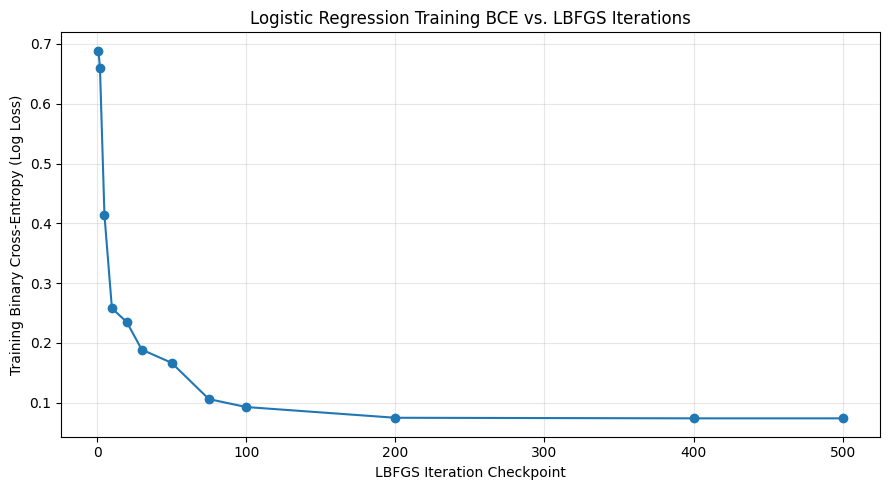

The curve should decrease and gradually flatten as the optimizer approaches a stable minimum.


In [ ]:
#  Plot Training Loss Across Iterations

plt.figure(figsize=(9, 5))
plt.plot(checkpoints, train_losses, marker="o")
plt.title("Logistic Regression Training BCE vs. LBFGS Iterations")
plt.xlabel("LBFGS Iteration Checkpoint")
plt.ylabel("Training Binary Cross-Entropy (Log Loss)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(
    "The curve should decrease and gradually flatten as the optimizer "
    "approaches a stable minimum."
)


In [ ]:
from sklearn.metrics import hinge_loss

svc_checkpoints = [1, 2, 5, 10, 20, 30, 50, 75, 100, 200, 400, 500]

svc_train_losses = []
svc_actual_iterations = []

with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    for checkpoint in svc_checkpoints:
        convergence_svc_model = LinearSVC(
            C=best_svc_C,
            max_iter=checkpoint,
            random_state=SEED,
            dual=False,
        )
        convergence_svc_model.fit(X_train, y_train)

        train_decision_scores = convergence_svc_model.decision_function(X_train)
        loss = hinge_loss(y_train, train_decision_scores, labels=[0, 1])

        svc_train_losses.append(loss)
        svc_actual_iterations.append(int(convergence_svc_model.n_iter_))

svc_convergence_table = pd.DataFrame({
    "LinearSVC iteration checkpoint": svc_checkpoints,
    "Reported optimizer iterations": svc_actual_iterations,
    "Training Hinge Loss": svc_train_losses,
})

display(svc_convergence_table)

,LinearSVC iteration checkpoint,Reported optimizer iterations,Training Hinge Loss
0,1,1,0.673181
1,2,2,0.524726
2,5,5,0.321339
3,10,10,0.221956
4,20,12,0.221016
5,30,12,0.221016
6,50,12,0.221016
7,75,12,0.221016
8,100,12,0.221016
9,200,12,0.221016


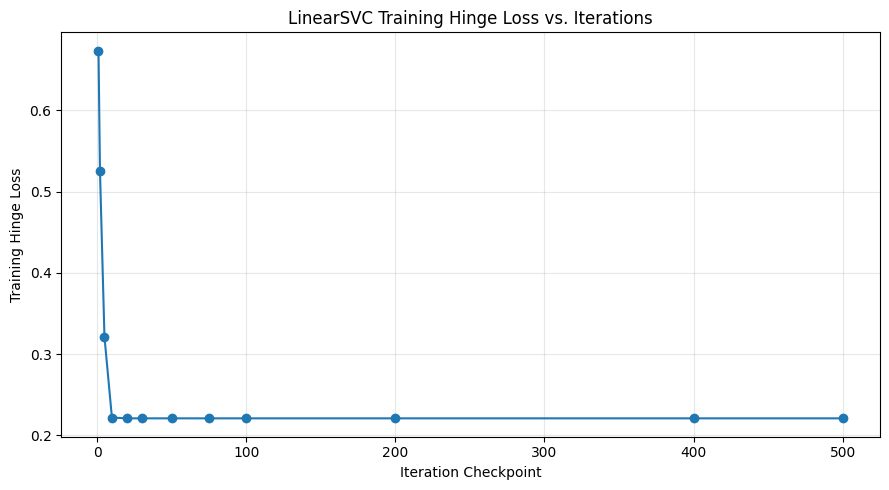

The curve should decrease and gradually flatten as the optimizer approaches a stable minimum.


In [ ]:
#  Plot Training Loss Across Iterations (SVC)

plt.figure(figsize=(9, 5))
plt.plot(svc_checkpoints, svc_train_losses, marker="o")
plt.title("LinearSVC Training Hinge Loss vs. Iterations")
plt.xlabel("Iteration Checkpoint")
plt.ylabel("Training Hinge Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(
    "The curve should decrease and gradually flatten as the optimizer "
    "approaches a stable minimum."
)

**Threshold Experiment**

In [ ]:
thresholds = [0.3, 0.5, 0.7]
threshold_rows = []

for threshold in thresholds:
    preds = (test_probabilities >= threshold).astype(int)

    threshold_rows.append({
        "Threshold (τ)": threshold,
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1-Score": f1_score(y_test, preds, zero_division=0),
        "Positive Predictions": int(preds.sum()),
    })

threshold_table = pd.DataFrame(threshold_rows)

display(
    threshold_table.style.format({
        "Threshold (τ)": "{:.1f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "Positive Predictions": "{:,}",
    })
)


,Threshold (τ),Precision,Recall,F1-Score,Positive Predictions
0,0.3,0.8509,0.9072,0.8781,"5,306"
1,0.5,0.8749,0.8712,0.8730,"4,956"
2,0.7,0.8961,0.8280,0.8607,"4,599"


In [ ]:
# Extract and Print Two False Positives and Two False Negatives

test_results = pd.DataFrame({
    "review": X_test_text.values,
    "true_label": y_test.values,
    "probability_positive": test_probabilities,
    "predicted_label": test_predictions,
}, index=X_test_text.index)

false_positives = test_results[
    (test_results["true_label"] == 0) &
    (test_results["predicted_label"] == 1)
].sort_values("probability_positive", ascending=False)

false_negatives = test_results[
    (test_results["true_label"] == 1) &
    (test_results["predicted_label"] == 0)
].sort_values("probability_positive", ascending=True)

print("=" * 90)
print("TWO FALSE POSITIVES")
print("=" * 90)

for i, (_, row) in enumerate(false_positives.head(2).iterrows(), start=1):
    print(f"\nFalse Positive #{i}")
    print(f"True label: Negative (0)")
    print(f"Predicted: Positive (1)")
    print(f"Predicted P(Positive): {row['probability_positive']:.6f}")
    print("-" * 90)
    print(row["review"])

print("\n" + "=" * 90)
print("TWO FALSE NEGATIVES")
print("=" * 90)

for i, (_, row) in enumerate(false_negatives.head(2).iterrows(), start=1):
    print(f"\nFalse Negative #{i}")
    print(f"True label: Positive (1)")
    print(f"Predicted: Negative (0)")
    print(f"Predicted P(Positive): {row['probability_positive']:.6f}")
    print("-" * 90)
    print(row["review"])

assert len(false_positives) >= 2, "Fewer than two False Positives were found."
assert len(false_negatives) >= 2, "Fewer than two False Negatives were found."


TWO FALSE POSITIVES

False Positive #1
True label: Negative (0)
Predicted: Positive (1)
Predicted P(Positive): 1.000000
------------------------------------------------------------------------------------------
finally opportunity watch zombie zombie flesheaters europe import region japanese dvd blow away entertain zombie epic transfer immaculate good ever go look unless anchor bay get hold gore truly stand like really appreciate excellent makeup gore fx sound also terrific channel dolby but receiver dolby prologic really appreciate cheesy music actually good score effective although cheap sound effect NOT sound NOT NOT good excellent transfer add overall enjoyment NOT realize NOT NOT NOT much NOT blood NOT flow NOT NOT NOT film extremely brutal explode head shots explode puss fill mega pimples cleaver zombies throat woman burn extremities come nt burn guy also intestinal munch zombie baby much lose track NOT doubt NOT NOT hardcore NOT zombie NOT action NOT fan especially italian kind 

In [ ]:
# Helper: Generate an analysis worksheet for the four errors

error_rows = []

for error_type, subset in [
    ("False Positive", false_positives.head(2)),
    ("False Negative", false_negatives.head(2)),
]:
    for number, (idx, row) in enumerate(subset.iterrows(), start=1):
        error_rows.append({
            "Error": f"{error_type} #{number}",
            "Dataset index": idx,
            "True label": int(row["true_label"]),
            "P(Positive)": row["probability_positive"],
            "Your diagnostic notes": (
                "Identify sentiment words, negation, sarcasm, mixed sentiment, "
                "or context/word-order clues."
            ),
        })

error_worksheet = pd.DataFrame(error_rows)
display(error_worksheet)


,Error,Dataset index,True label,P(Positive),Your diagnostic notes
0,False Positive #1,11162,0,1.000000e+00,"Identify sentiment words, negation, sarcasm, mixed sentiment, or context/word-order clues."
1,False Positive #2,37118,0,1.000000e+00,"Identify sentiment words, negation, sarcasm, mixed sentiment, or context/word-order clues."
2,False Negative #1,13773,1,3.842497e-12,"Identify sentiment words, negation, sarcasm, mixed sentiment, or context/word-order clues."
3,False Negative #2,43276,1,2.205037e-09,"Identify sentiment words, negation, sarcasm, mixed sentiment, or context/word-order clues."


In [ ]:
coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

top_positive = (
    coef_df
    .nlargest(10, "coefficient")
    .sort_values("coefficient", ascending=False)
)

top_negative = (
    coef_df
    .nsmallest(10, "coefficient")
    .sort_values("coefficient", ascending=True)
)

print("Top 10 Positive Features:")
display(top_positive)

print("\nTop 10 Negative Features:")
display(top_negative)


Top 10 Positive Features:


,feature,coefficient
5823,not disappoint,2.325278
3126,flawless,2.053501
1722,cope,1.850940
7524,refresh,1.847443
2397,eisenstein,1.835582
1602,complaint,1.811641
4745,lot things,1.810120
3188,fortunate,1.798517
945,brilliantly,1.790657
8976,thick,1.749295



Top 10 Negative Features:


,feature,coefficient
3179,forgettable,-2.478474
2171,disappointment,-2.282086
6688,one worst,-2.182454
7370,rainy,-2.062303
9409,unlikeable,-2.024517
7180,pretentious,-1.918213
564,awful,-1.867038
5387,mst,-1.854442
8839,tack,-1.842239
2813,fast forward,-1.805850


In [ ]:
print(df.groupby("sentiment")["clean_review"].apply(
    lambda x: x.str.contains("not_great", case=False, na=False).sum()
))
print("it make sense")

sentiment
0    0
1    0
Name: clean_review, dtype: int64
it make sense


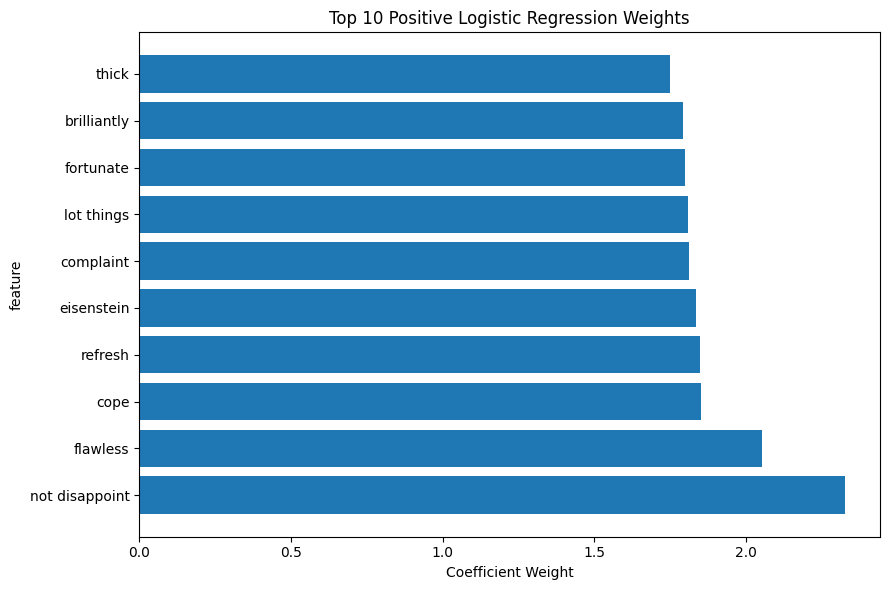

In [ ]:
plt.figure(figsize=(9, 6))
plt.barh(top_positive["feature"], top_positive["coefficient"])
plt.title("Top 10 Positive Logistic Regression Weights")
plt.xlabel("Coefficient Weight")
plt.ylabel("feature")
plt.tight_layout()
plt.show()


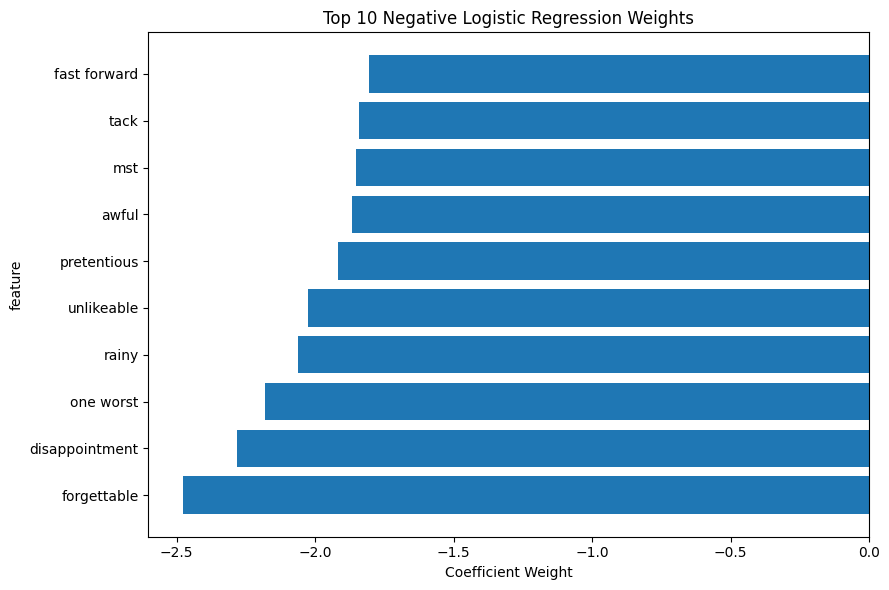

In [ ]:
plt.figure(figsize=(9, 6))
plt.barh(top_negative["feature"], top_negative["coefficient"])
plt.title("Top 10 Negative Logistic Regression Weights")
plt.xlabel("Coefficient Weight")
plt.ylabel("feature")
plt.tight_layout()
plt.show()


In [ ]:
print("just test")
sentiment_words = [
    "excellent",
    "amazing",
    "wonderful",
    "great",
    "fantastic",
    "perfect",
    "terrible",
    "awful",
    "horrible",
    "worst",
    "boring",
    "waste"
]

sentiment_check = coef_df[
    coef_df["feature"].isin(sentiment_words)
].sort_values("coefficient", ascending=False)

display(sentiment_check)

just test


,feature,coefficient
6908,perfect,1.280970
2657,excellent,1.276897
2792,fantastic,1.087946
9822,wonderful,0.952875
3575,great,0.753900
8938,terrible,-1.104802
9631,waste,-1.405424
3885,horrible,-1.445513
9860,worst,-1.487573
564,awful,-1.867038


In [ ]:
#  Reusable Prediction Function

def predict_sentiment(review_text: str, threshold: float = 0.5):
    if not isinstance(review_text, str):
        raise TypeError("review_text must be a string.")

    if not 0.0 <= threshold <= 1.0:
        raise ValueError("threshold must be between 0 and 1.")

    review_vector = vectorizer.transform([review_text])

    probability_positive = float(model.predict_proba(review_vector)[0, 1])

    logit = float(model.decision_function(review_vector)[0])

    probability_negative = 1.0 - probability_positive

    predicted_class = (
        "Positive" if probability_positive >= threshold else "Negative"
    )

    return {
        "predicted_class": predicted_class,
        "probability_positive": probability_positive,
        "probability_negative": probability_negative,
        "logit": logit,
        "threshold": threshold,
    }


print("predict_sentiment() is ready.")


predict_sentiment() is ready.


In [ ]:
benchmark_reviews = [
    "An absolute triumph of cinema with breathtaking visuals and stellar acting.",
    "I thoroughly enjoyed wasting two hours of my life staring at a completely incoherent plot.",
    "The cinematography was not bad, but the pacing was not good either.",
]

benchmark_results = []

for review in benchmark_reviews:
    result = predict_sentiment(review, threshold=0.5)

    benchmark_results.append({
        "Review": review,
        "Prediction": result["predicted_class"],
        "P(Positive)": result["probability_positive"],
        "P(Negative)": result["probability_negative"],
        "Logit (z)": result["logit"],
    })

benchmark_table = pd.DataFrame(benchmark_results)

display(
    benchmark_table.style.format({
        "P(Positive)": "{:.6f}",
        "P(Negative)": "{:.6f}",
        "Logit (z)": "{:.6f}",
    })
)


,Review,Prediction,P(Positive),P(Negative),Logit (z)
0,An absolute triumph of cinema with breathtaking visuals and stellar acting.,Positive,0.817581,0.182419,1.500041
1,I thoroughly enjoyed wasting two hours of my life staring at a completely incoherent plot.,Negative,0.157033,0.842967,-1.680474
2,"The cinematography was not bad, but the pacing was not good either.",Negative,0.173347,0.826653,-1.562091
